# Opening the "Black Box"
## Act II — Why does making the model *bigger* help?

**Universidad Panamericana — May 21, 2026** · Eduardo Dueñez, UTSA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/public-site/blob/main/2026-UPanamericana-mathAI/notebooks/act2_double_descent_demo.ipynb)

---

Live demo for **Act II** of the talk. We will tell two stories:

1. **The classical wisdom (1990s).** A *bias–variance* tradeoff: too few parameters
   underfit, too many overfit. There is an optimal "Goldilocks" capacity in the middle.
   We see this clearly with **polynomial regression** in 1D.
2. **The modern picture (Belkin et al.\ 2019).** With a *numerically stable* model
   class — for instance, a neural network with bounded activations — pushing the
   number of parameters *past* the data size makes the model generalize *better*
   again. Empirically: **double descent**.

By the end we land the second **mathematical surprise** of the talk, and we will see
*why* the basis matters.


---
# 0. Setup

This notebook runs on **Google Colab** and **local Jupyter**. No external models or downloads.


In [1]:
# @title Runtime setup (run me first)
import os, subprocess, sys

try:
    import google.colab  # noqa: F401
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "ipywidgets"],
        check=False,
    )
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

np.random.seed(7)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "figure.dpi": 100,
})

print(f"NumPy {np.__version__}")
print(f"Running on {'Colab' if _IN_COLAB else 'local Jupyter'}")


NumPy 2.4.4
Running on local Jupyter


---
# 1. The classical picture: three regimes

We fit polynomials of varying degree $d$ to **noisy samples of $f(x) = \sin(x)$** on
$[0, 2\pi]$. Each fit is the least-squares polynomial of degree $d$.

Classical textbook picture: three qualitative behaviors.


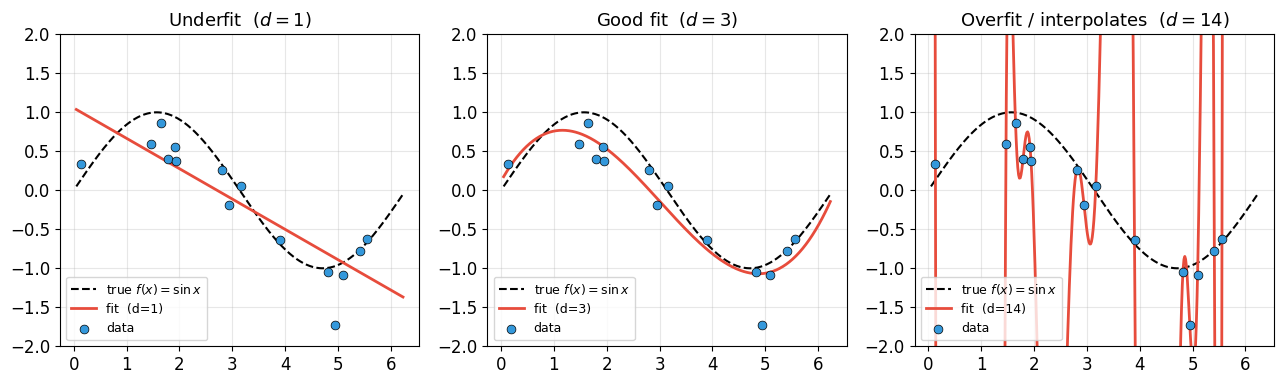

In [2]:
# ── Data: noisy samples of sin(x) ────────────────────────────────────────
N = 15
NOISE = 0.30
rng = np.random.default_rng(7)
X = np.sort(rng.uniform(0.1, 2*np.pi - 0.1, N))
y = np.sin(X) + NOISE * rng.standard_normal(N)

def normalize(x): return 2.0 * x / (2*np.pi) - 1.0
Xn = normalize(X)

def fit_poly(Xn_train, y_train, Xn_eval, degree):
    """Min-norm least-squares polynomial fit using a Vandermonde basis."""
    Phi_tr = np.vander(Xn_train, degree + 1, increasing=True)
    Phi_ev = np.vander(Xn_eval,  degree + 1, increasing=True)
    beta, *_ = np.linalg.lstsq(Phi_tr, y_train, rcond=None)
    return Phi_ev @ beta

x_plot = np.linspace(0.05, 2*np.pi - 0.05, 400)
xp_n   = normalize(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, deg, label in zip(
    axes,
    [1, 3, 14],
    ["Underfit  ($d = 1$)", "Good fit  ($d = 3$)", "Overfit / interpolates  ($d = 14$)"]
):
    y_pred = fit_poly(Xn, y, xp_n, deg)
    y_pred = np.clip(y_pred, -3, 3)
    ax.plot(x_plot, np.sin(x_plot), "k--", lw=1.5, label=r"true $f(x)=\sin x$")
    ax.plot(x_plot, y_pred,        "-",   lw=2.0, color="#e74c3c", label=f"fit  (d={deg})")
    ax.scatter(X, y, c="#3498db", edgecolors="k", lw=0.5, s=40, zorder=3, label="data")
    ax.set_ylim(-2.0, 2.0); ax.set_title(label); ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()


---
# 2. The classical U-curve

Now we sweep the degree $d$ from $1$ up to $12$ (i.e., $p = d + 1 \le N = 15$) and plot:

- **Training error** on the data the model saw.
- **Test error** on the underlying truth $\sin(x)$, evaluated on a dense grid.

We expect the canonical *bias–variance U-curve*: test error drops, hits an optimum,
then rises again.


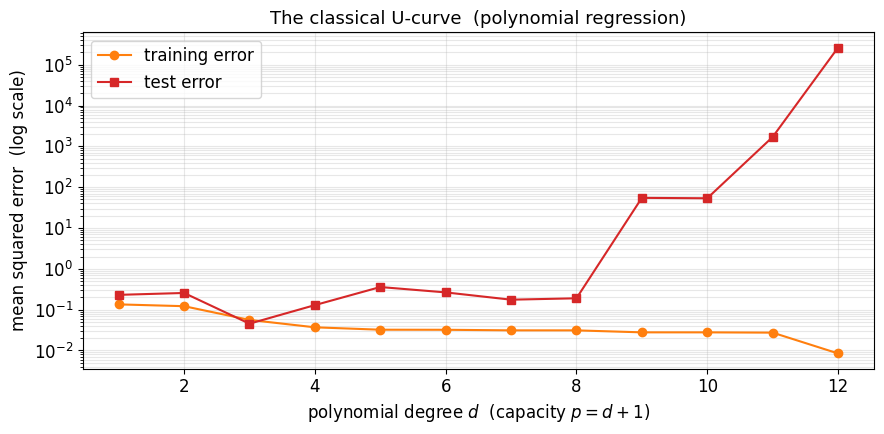

best classical degree: d = 3


In [3]:
x_test = np.linspace(0.05, 2*np.pi - 0.05, 500)
y_test = np.sin(x_test)
xt_n   = normalize(x_test)

def poly_errors(d):
    y_train_pred = fit_poly(Xn, y, Xn,   d)
    y_test_pred  = fit_poly(Xn, y, xt_n, d)
    return (np.mean((y_train_pred - y)**2),
            np.mean((y_test_pred - y_test)**2))

degrees = np.arange(1, 13)            # classical regime: d ≤ N - 3
err_tr_poly = np.array([poly_errors(d)[0] for d in degrees])
err_te_poly = np.array([poly_errors(d)[1] for d in degrees])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(degrees, err_tr_poly, "-o", color="#ff7f0e", label="training error")
ax.semilogy(degrees, err_te_poly, "-s", color="#d62728", label="test error")
ax.set_xlabel(r"polynomial degree $d$  (capacity $p = d + 1$)")
ax.set_ylabel("mean squared error  (log scale)")
ax.set_title("The classical U-curve  (polynomial regression)")
ax.grid(True, alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

print(f"best classical degree: d = {degrees[err_te_poly.argmin()]}")


---
# 3. What if we *keep going* past the threshold?

The classical wisdom — "test error always rises past $d \approx N$" — does fail for some
model classes. But it's *true* for polynomial regression. The reason is a numerical one.

> **Speaker's observation.** A polynomial basis $\{1, x, x^2, x^3, \ldots\}$ on a non-trivial
> interval has **no fixed scale**: each new degree $x^d$ has unboundedly larger magnitude
> than the previous one. Once $d$ approaches the data size, the design matrix becomes
> catastrophically ill-conditioned, and least-squares — even minimum-norm least-squares —
> produces wildly oscillating fits.

So if we want to see what happens past the interpolation threshold, we have to switch to
a **basis with bounded features**.

A natural choice — and the one Act I's neural network was secretly using — is

$$
\phi_k(x) \;=\; \operatorname{ReLU}\!\bigl(\mathbf{w}_k^{\top}\mathbf{x} + b_k\bigr)\;\big/\;\sqrt{p},
$$

with $\mathbf{w}_k, b_k$ **drawn randomly once and frozen**. Each $\phi_k$ is bounded, the
$1/\sqrt{p}$ keeps the model's overall scale stable as $p$ grows, and the basis is
"numerically tame" at any $p$.

This is literally **a single-hidden-layer neural network with the first layer fixed**; the
last layer (the $\beta_k$ coefficients) is what we fit by least squares. It is the simplest
non-trivial neural model and the one Belkin–Hsu–Ma–Mandal (2019) used to *introduce*
double descent.

Drag the slider below and watch the curve **bend back down** past the threshold.


In [4]:
# ── 10-dimensional linear-regression problem ─────────────────────────────
# A neural network is most naturally a function of vector inputs. We pose the
# regression problem in R^10 so the random ReLU features have something to learn.

D_TRUE = 10
N_HD   = 50            # interpolation threshold sits at p = 50
SIGMA  = 0.5

rng_data = np.random.default_rng(7)
beta_true = rng_data.standard_normal(D_TRUE) / np.sqrt(D_TRUE)
X_tr_hd = rng_data.standard_normal((N_HD, D_TRUE))
y_tr_hd = X_tr_hd @ beta_true + SIGMA * rng_data.standard_normal(N_HD)

N_TE = 1000
X_te_hd = rng_data.standard_normal((N_TE, D_TRUE))
y_te_hd = X_te_hd @ beta_true                     # noiseless test ground truth

# ── Random ReLU features (first layer frozen at random) ──────────────────
P_MAX = 250
rng_feat = np.random.default_rng(42)
W_all = rng_feat.standard_normal((P_MAX, D_TRUE)) / np.sqrt(D_TRUE)
b_all = rng_feat.uniform(-1.0, 1.0, P_MAX)

def relu_features(X, p):
    return np.maximum(X @ W_all[:p].T + b_all[:p], 0) / np.sqrt(p)

def fit_relu(p):
    Phi_tr = relu_features(X_tr_hd, p)
    Phi_te = relu_features(X_te_hd, p)
    beta, *_ = np.linalg.lstsq(Phi_tr, y_tr_hd, rcond=None)
    return Phi_tr @ beta, Phi_te @ beta

# ── Pre-compute train/test errors across the full sweep ──────────────────
ps_hd  = np.arange(2, P_MAX + 1)
err_tr_hd = np.empty(len(ps_hd))
err_te_hd = np.empty(len(ps_hd))
for i, p in enumerate(ps_hd):
    y_tr_pred, y_te_pred = fit_relu(p)
    err_tr_hd[i] = np.mean((y_tr_pred - y_tr_hd) ** 2)
    err_te_hd[i] = np.mean((y_te_pred - y_te_hd) ** 2)

# ── Interactive renderer ─────────────────────────────────────────────────
def render(p):
    _, y_te_pred = fit_relu(p)
    idx = p - 2
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))

    # LEFT — predicted vs. true on the test set
    axL.scatter(y_te_hd, y_te_pred, s=10, alpha=0.4, c="#e74c3c")
    diag = [y_te_hd.min(), y_te_hd.max()]
    axL.plot(diag, diag, "k--", lw=1)
    axL.set_xlabel("true  $y$"); axL.set_ylabel(r"predicted  $\hat y$")
    axL.set_title(f"Test predictions  (p = {p})")
    axL.set_aspect("equal"); axL.grid(alpha=0.3)
    # Keep a stable viewport so the spread is visible at all p
    axL.set_xlim(-3, 3); axL.set_ylim(-6, 6)

    # RIGHT — train / test error curves
    axR.semilogy(ps_hd, err_tr_hd, "-", color="#ff7f0e", lw=1.5, label="train MSE")
    axR.semilogy(ps_hd, err_te_hd, "-", color="#d62728", lw=1.5, label="test MSE")
    axR.axvline(N_HD, ls="--", color="purple", alpha=0.7,
                label=f"interpolation threshold  p = N = {N_HD}")
    axR.axvline(p, color="black", lw=1.5, alpha=0.8)
    axR.scatter([p], [err_tr_hd[idx]], color="#ff7f0e",
                edgecolors="k", lw=0.5, zorder=5)
    axR.scatter([p], [err_te_hd[idx]], color="#d62728",
                edgecolors="k", lw=0.5, zorder=5)
    axR.set_ylim(1e-3, 1e2)
    axR.set_xlabel("p  (hidden-layer width / number of random ReLU features)")
    axR.set_ylabel("MSE  (log scale)")
    axR.grid(alpha=0.3, which="both"); axR.legend(fontsize=9, loc="upper right")
    axR.set_title("Train / test error  vs. capacity")
    axR.text(0.98, 0.02,
             f"p = {p}\ntrain MSE = {err_tr_hd[idx]:.3g}\ntest  MSE = {err_te_hd[idx]:.3g}",
             transform=axR.transAxes, ha="right", va="bottom",
             family="monospace", fontsize=10,
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85))

    plt.tight_layout(); plt.show()

slider = widgets.IntSlider(
    value=20, min=2, max=P_MAX, step=1, description="features p",
    continuous_update=False,
    layout=widgets.Layout(width="80%"),
)
out = widgets.interactive_output(render, {"p": slider})
display(widgets.VBox([slider, out]))


---
# 🎉 Surprise #2 — Over-parameterization works

**Drag the slider** and the canonical empirical discovery of modern statistical learning
appears in one continuous gesture:

1. **Up to $p \approx N$** — the *classical* U-curve. Bias dominates at small $p$,
   variance at moderate $p$.
2. **At $p = N$** — interpolation threshold. Training error hits the noise floor.
   Test error **spikes** sharply.
3. **Past $p = N$** — **second descent**. Test error falls again, often **below**
   the classical minimum.

This contradicts every pre-2018 statistics textbook.

> **Belkin–Hsu–Ma–Mandal (2019), *Reconciling modern machine learning and the
> classical bias–variance trade-off*.** For random feature models, kernel methods, and
> neural networks, the test error as a function of model capacity exhibits a
> double-descent shape.

The mechanism, qualitatively:

- **Below threshold** ($p \ll N$): too rigid → bias dominates.
- **At threshold** ($p \approx N$): the fit is uniquely determined and forced through
  every noise point → variance explodes.
- **Above threshold** ($p \gg N$): infinitely many parameter vectors interpolate the
  data. The *minimum-norm* one — the one `lstsq` (and, by an analogous mechanism, SGD)
  actually finds — is **smooth**. Among all interpolators, smoothness corresponds to
  good generalization.

> **Why polynomial regression *cannot* show this.** Polynomial features
> $\{1, x, x^2, \ldots, x^d\}$ have no fixed scale: each new feature is unboundedly larger
> than the previous one on any non-trivial interval. The minimum-norm solution past the
> threshold is dominated by the high-degree features and has huge coefficients, not small
> ones. The basis itself is not "numerically tame."
>
> **The neural-network basis is special.** Activations like $\operatorname{ReLU}$,
> $\sigma$, $\tanh$, $\operatorname{GeLU}$ are all 1-Lipschitz and map $0$ to $0$. With
> $1/\sqrt p$ normalization, the entire model has a Lipschitz constant bounded by a
> product of weight norms — *independent of width*. This is the **structural property**
> that makes double descent appear, and it is the property modern deep architectures
> work hard to preserve (layer norm, residual connections, careful initialization).

> **Open problem.** Why is the minimum-norm interpolator so often the *right* one?
> Why does SGD on a non-convex loss surface, started from random weights, find a good
> minimum in 30 seconds out of infinitely many bad ones nearby?
>
> *We have a partial theory for kernel and random-feature regression. We do not have one
> for deep neural networks. This is one of the most important open problems in
> mathematical machine learning.*

This is the motivation for **scaling laws** — and the rationale behind every
100-billion-parameter language model. Bigger really is better, once you cross the
threshold *and* keep the architecture numerically tame.

Up next (Act III): inside one of those very large models.
